## Project Note

This project is based on an NLP analysis originally developed as part of a university research project on the perception of artificial intelligence in public discourse.

The original analysis was conducted on a larger dataset that cannot be publicly redistributed due to data access and licensing restrictions. Therefore, this GitHub repository contains a separate, small demonstration dataset consisting of 30 synthetic Reddit-style entries created specifically for this portfolio project.

The demonstration dataset was generated with the assistance of ChatGPT and designed to reproduce relevant linguistic characteristics and the analytical structure of the original data, without exposing or redistributing any protected source material.

The purpose of this repository is to demonstrate the NLP methodology, analytical workflow, and implementation rather than to reproduce the findings of the original university project. Results obtained from the demonstration dataset should therefore be interpreted as examples of the analytical pipeline and not as conclusions about Reddit users or public attitudes towards AI.

### *Sentiment AI in Discourse*

In [1]:
import pandas as pd
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0

def extract_query(filename):
    return filename.replace(".tsv", "")

def is_german(text):
    try:
        return detect(str(text)) == "de"
    except Exception:
        return False

def load_and_clean(file_path, query_name):
    df = pd.read_csv(file_path, sep="\t")

    df["text"] = (
        df["ContextBefore"].fillna("").astype(str) + " " +
        df["Hit"].fillna("").astype(str) + " " +
        df["ContextAfter"].fillna("").astype(str)
    ).str.strip()

    df = df.drop_duplicates(subset=["text"])
    df = df[df["text"].str.len() > 30]

    df["query"] = query_name

    if "Date" in df.columns:
        df["date"] = pd.to_datetime(df["Date"], errors="coerce")
        df["year"] = df["date"].dt.year
    else:
        df["date"] = pd.NaT
        df["year"] = pd.NA

    return df[["text", "query", "date", "year"]]

files = ["sample_data.tsv"]

all_data = []

for f in files:
    query_name = extract_query(f)
    cleaned = load_and_clean(f, query_name)
    all_data.append(cleaned)

df_all = pd.concat(all_data, ignore_index=True)

print(f"Rows before language filter: {len(df_all)}")

df_all = df_all[df_all["text"].apply(is_german)]

print(f"Rows after language filter: {len(df_all)}")

df_all.to_csv("cleaned.csv", index=False)
df_all.to_excel("cleaned.xlsx", index=False)

print("Done")

Rows before language filter: 29
Rows after language filter: 29
Done


Loaded 29 rows.
Number of unique sentences after deduplication: 29
Running model on: cpu
id2label: {0: 'positive', 1: 'negative', 2: 'neutral'}


Sentiment analysis: 100%|████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.46s/it]

[checkpoint] saved 29 results to sentences_with_sentiment.csv
Saved aggregation to: sentiment_over_time_percent.csv
label   negative    neutral   positive
year                                  
2020   16.666667  83.333333   0.000000
2021   60.000000  40.000000   0.000000
2022   33.333333  33.333333  33.333333
2023   50.000000  50.000000   0.000000
2024   50.000000  33.333333  16.666667


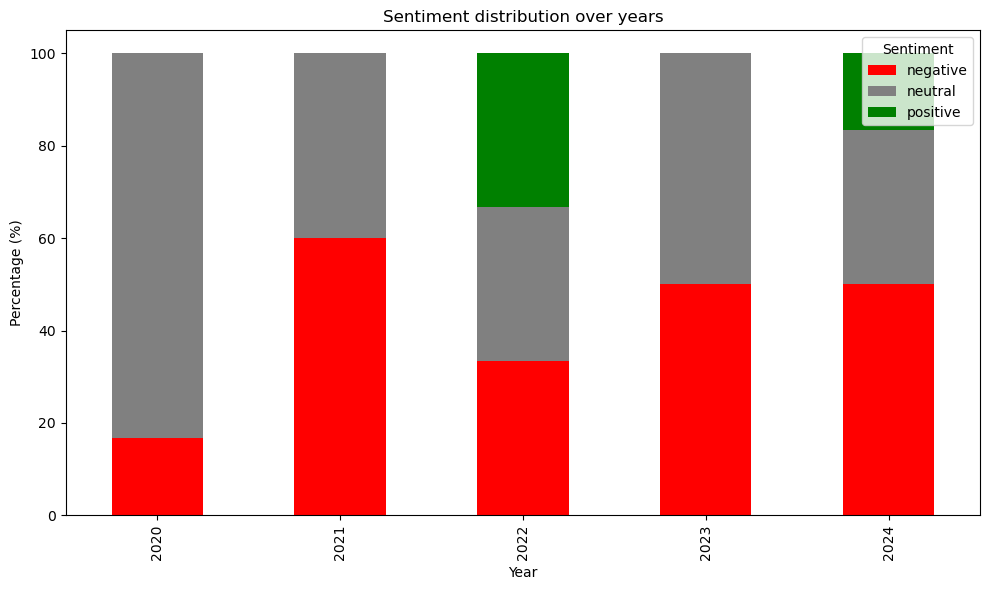

In [2]:
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import matplotlib.pyplot as plt

INPUT_CSV = "cleaned.csv"
OUTPUT_SENTENCES_CSV = "sentences_with_sentiment.csv"
OUTPUT_AGG_CSV = "sentiment_over_time_percent.csv"
MODEL_NAME = "oliverguhr/german-sentiment-bert"
BATCH_SIZE = 64
MAX_LENGTH = 128
SAVE_EVERY_BATCHES = 50

df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} rows.")

df["text_norm"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()
df = df.drop_duplicates(subset=["text_norm"]).reset_index(drop=True)

print(f"Number of unique sentences after deduplication: {len(df)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running model on:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.to(device)
model.eval()

id2label = {int(k): v for k, v in model.config.id2label.items()}
print("id2label:", id2label)

all_labels = []
all_scores = []
texts = df["text_norm"].tolist()

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Sentiment analysis"):
    batch_texts = texts[i:i + BATCH_SIZE]

    enc = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        out = model(**enc)
        probs = F.softmax(out.logits, dim=-1).cpu().numpy()

    top_idx = probs.argmax(axis=1)
    top_prob = probs.max(axis=1)

    batch_labels = [id2label[int(idx)] for idx in top_idx]

    all_labels.extend(batch_labels)
    all_scores.extend(top_prob.tolist())

    if (i // BATCH_SIZE) % SAVE_EVERY_BATCHES == 0 or (i + BATCH_SIZE) >= len(texts):
        partial_df = pd.DataFrame({
            "text_norm": texts[:i + len(batch_texts)],
            "label": all_labels,
            "score": all_scores
        })

        partial_df.to_csv(
            OUTPUT_SENTENCES_CSV,
            index=False
        )

        print(
            f"[checkpoint] saved {len(partial_df)} results "
            f"to {OUTPUT_SENTENCES_CSV}"
        )

result_df = pd.read_csv(OUTPUT_SENTENCES_CSV)

merged = df.merge(
    result_df,
    on="text_norm",
    how="left"
)

agg = (
    merged.groupby(["year", "label"])
    .size()
    .unstack(fill_value=0)
)

for label in ["negative", "neutral", "positive"]:
    if label not in agg.columns:
        agg[label] = 0

agg = agg[
    ["negative", "neutral", "positive"]
]

agg_percent = (
    agg.div(agg.sum(axis=1), axis=0) * 100
)

agg_percent.to_csv(
    OUTPUT_AGG_CSV
)

print(f"Saved aggregation to: {OUTPUT_AGG_CSV}")
print(agg_percent)

agg_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["red", "gray", "green"]
)

plt.title("Sentiment distribution over years")
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

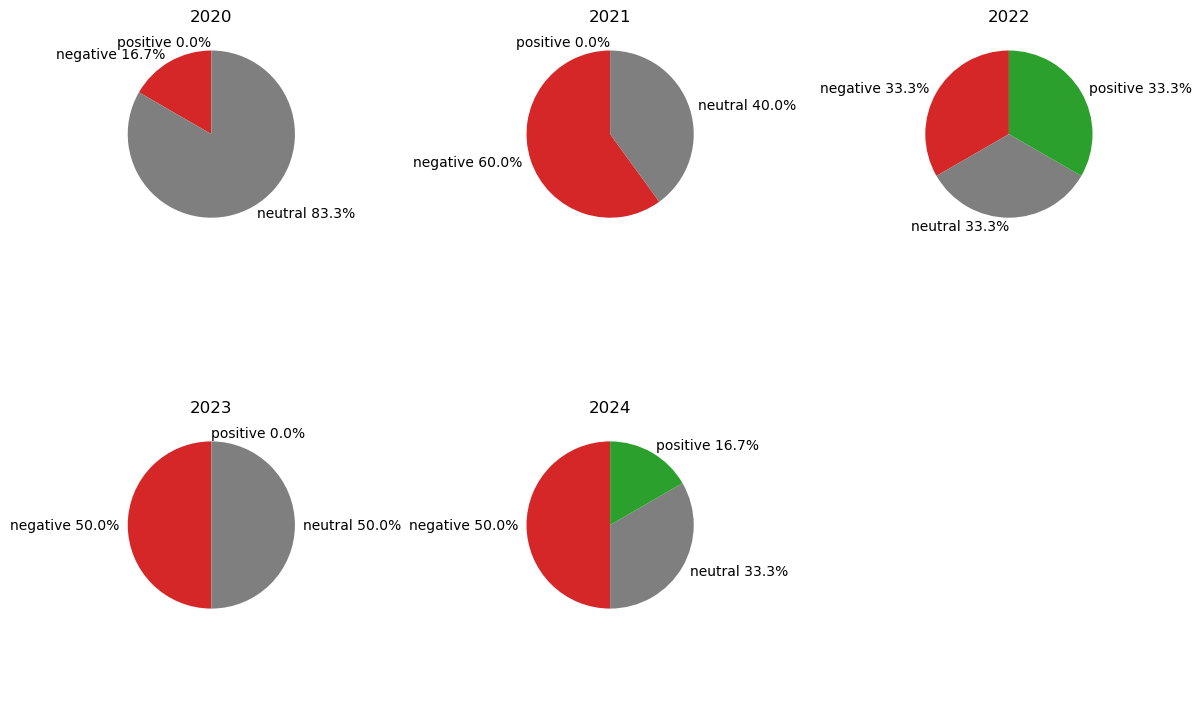

In [3]:
import math

colors = {
    "negative": "#d62728",
    "positive": "#2ca02c",
    "neutral": "#7f7f7f"
}

n_years = len(agg_percent.index)
cols = 3
rows = math.ceil(n_years / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, (year, row) in zip(axes, agg_percent.iterrows()):
    values = row.values
    labels = [
        f"{label} {value:.1f}%"
        for label, value in zip(agg_percent.columns, values)
    ]

    ax.pie(
        values,
        labels=labels,
        colors=[colors[label] for label in agg_percent.columns],
        autopct=None,
        startangle=90
    )

    ax.set_title(str(year))

for ax in axes[n_years:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
neg_examples = merged[merged["label"] == "negative"].head(10)
print("\nExamples of sentences with negative sentiment:")
print(neg_examples[["text", "label", "score"]])

neu_examples = merged[merged["label"] == "neutral"].head(10)
print("\nExamples of sentences with neutral sentiment:")
print(neu_examples[["text", "label", "score"]])

pos_examples = merged[merged["label"] == "positive"].head(10)
print("\nExamples of sentences with positive sentiment:")
print(pos_examples[["text", "label", "score"]])


Examples of sentences with negative sentiment:
                                                 text     label     score
0   ChatGPT ist heute wieder so unendlich faul, er...  negative  0.966208
4   Meine  KI App schmolz heute Morgen fast vor Sc...  negative  0.962605
7   Diese  artificial intelligence Systeme tun imm...  negative  0.958806
11  Ich spüre pure Wut, wenn  AI Midjourney meine ...  negative  0.986141
12  Gemini weigert sich hartnäckig, mir bei den Ha...  negative  0.994076
14  Es macht mir Angst, wie intelligent diese  art...  negative  0.861532
15  Ich habe  ChatGPT angeschrien und jetzt tut mi...  negative  0.982657
16  Die neue Sprachausgabe von  OpenAI atmet und s...  negative  0.968546
19  artificial intelligence versucht verzweifelt, ...  negative  0.987012
24  Gemini schmollt bestimmt wieder, weil das neue...  negative  0.977692

Examples of sentences with neutral sentiment:
                                                 text    label     score
1   Ich habe das G

### *BERT Analysis and Personification of AI*

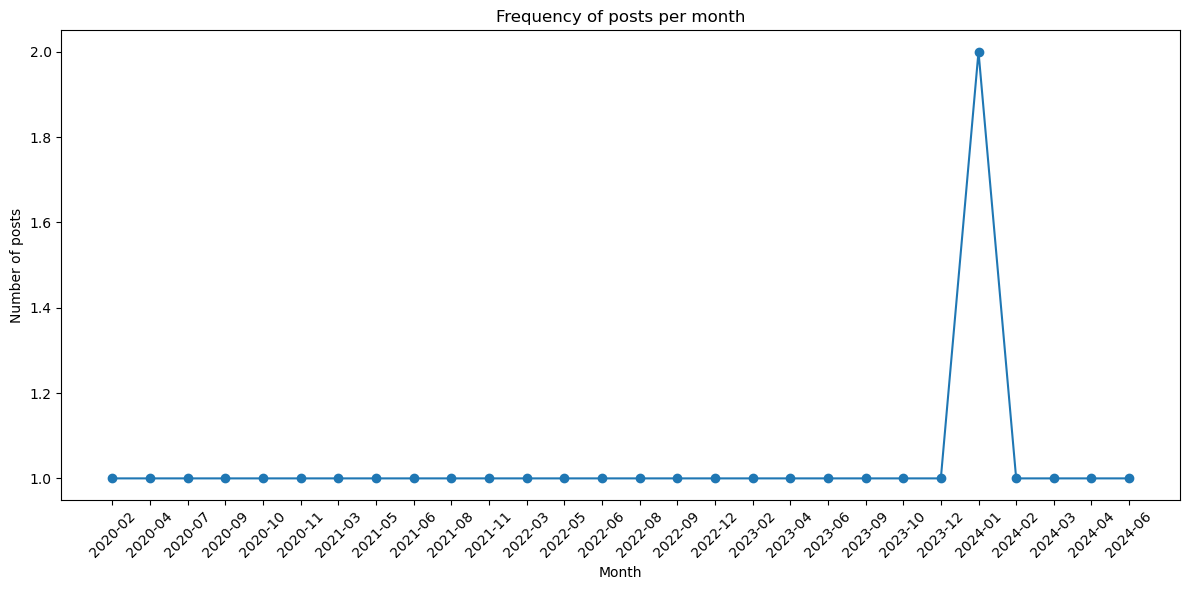

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned.csv")

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])

df["month"] = df["date"].dt.to_period("M")

monthly_counts = (
    df.groupby("month")
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_counts["month"].astype(str),
    monthly_counts["count"],
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Frequency of posts per month")
plt.xlabel("Month")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()

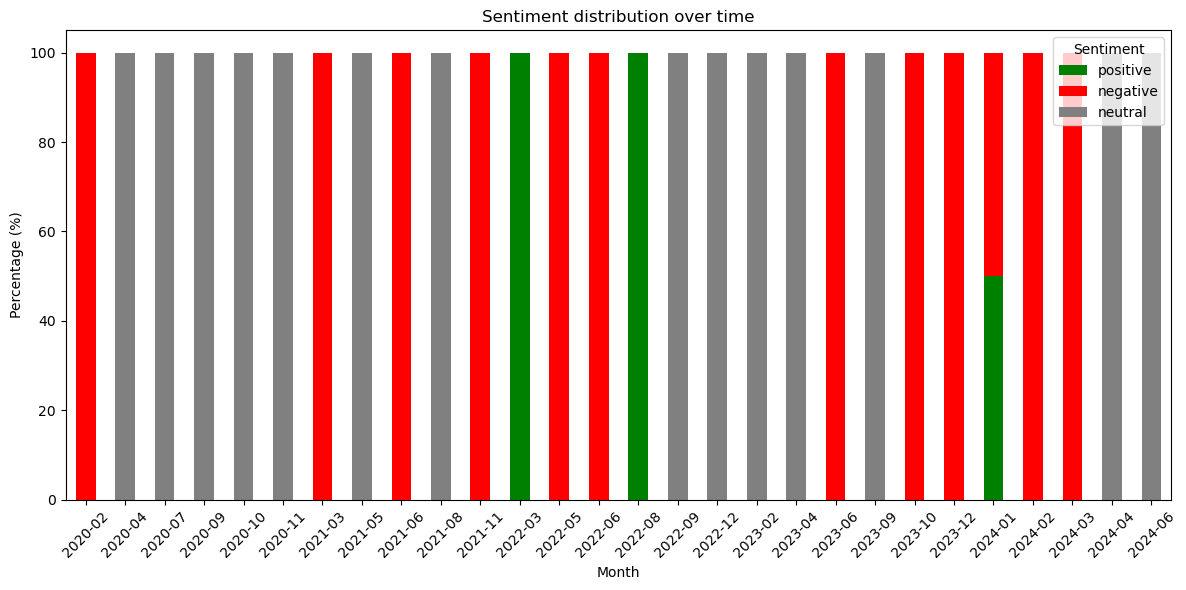

In [6]:
import matplotlib.pyplot as plt

merged["date"] = pd.to_datetime(merged["date"], errors="coerce")
merged = merged.dropna(subset=["date"])

merged["month"] = merged["date"].dt.to_period("M")

monthly_sentiment = (
    merged.groupby(["month", "label"])
    .size()
    .unstack(fill_value=0)
)

for label in ["positive", "negative", "neutral"]:
    if label not in monthly_sentiment.columns:
        monthly_sentiment[label] = 0

monthly_sentiment = monthly_sentiment[
    ["positive", "negative", "neutral"]
]

monthly_sentiment_percent = (
    monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0) * 100
)

monthly_sentiment_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["green", "red", "gray"]
)

plt.title("Sentiment distribution over time")
plt.xlabel("Month")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
monthly_sentiment_percent.to_csv(
    "monthly_sentiment_percent.csv",
    encoding="utf-8"
)

merged.to_csv(
    "cleaned_with_sentiment.csv",
    index=False,
    encoding="utf-8"
)

print("Saved monthly sentiment percentages and sentence-level sentiment results.")

Saved monthly sentiment percentages and sentence-level sentiment results.


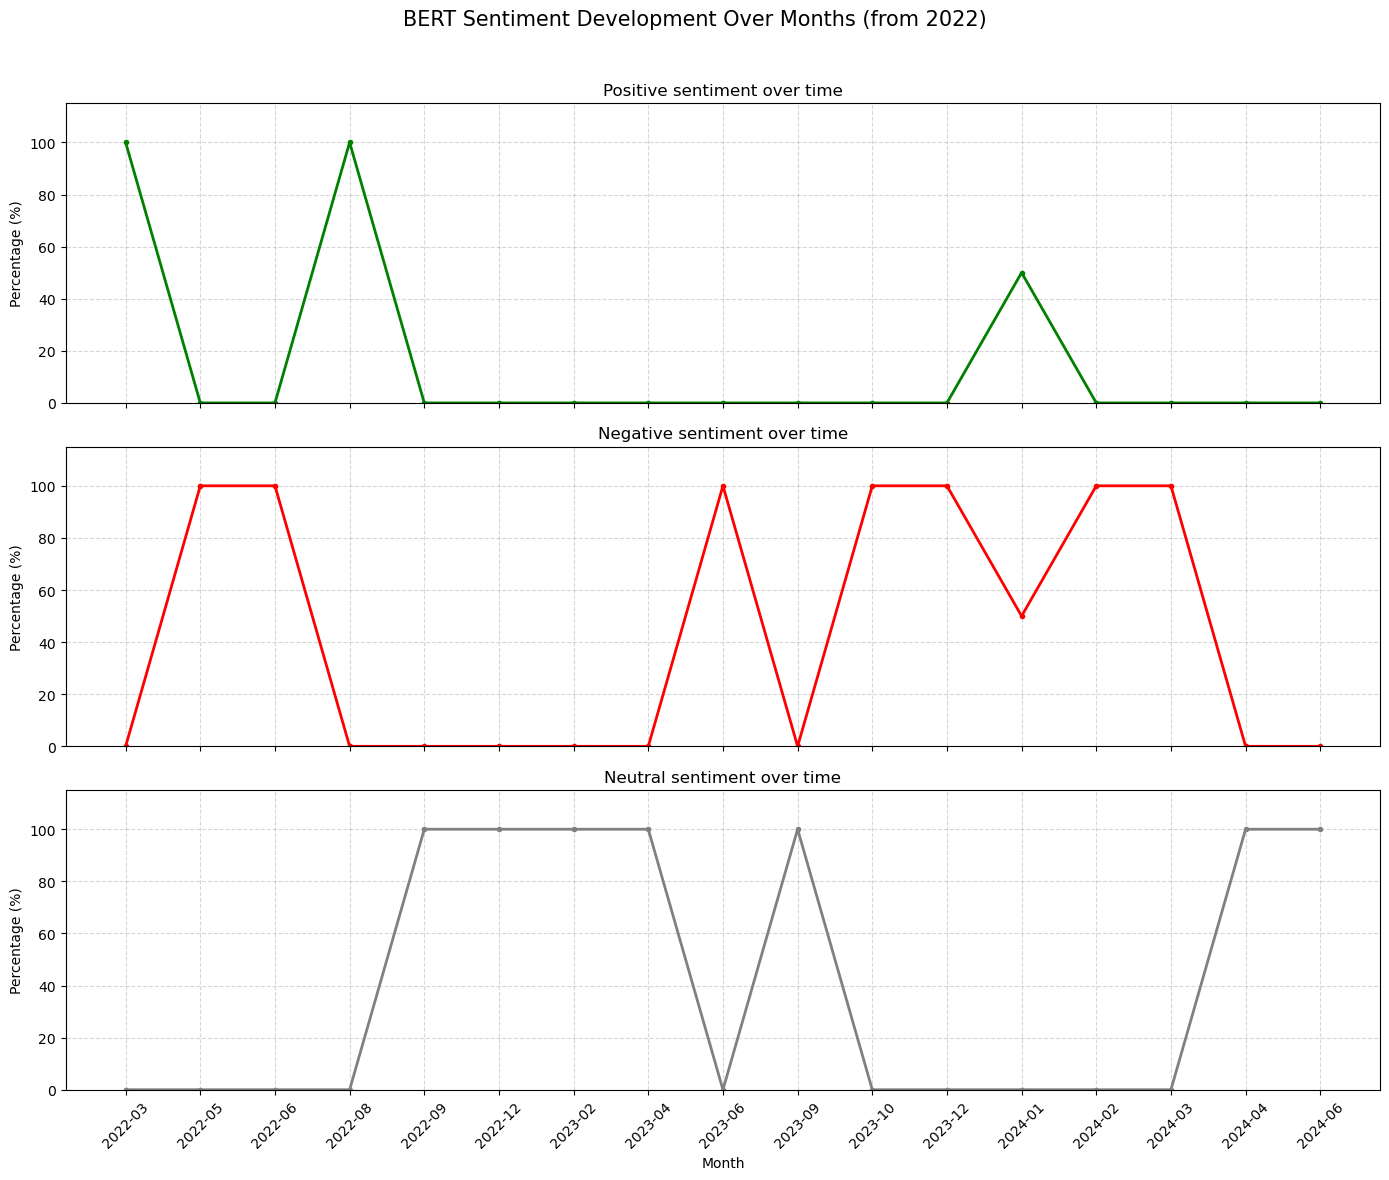

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

sentiment_percent = pd.read_csv(
    "monthly_sentiment_percent.csv",
    index_col=0
)

sentiment_percent.index = sentiment_percent.index.astype(str)

sentiment_percent = sentiment_percent[
    sentiment_percent.index >= "2022-01"
]

for col in ["positive", "negative", "neutral"]:
    if col not in sentiment_percent.columns:
        sentiment_percent[col] = 0

fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 12),
    sharex=True
)

sentiments = [
    ("positive", "Positive", "green"),
    ("negative", "Negative", "red"),
    ("neutral", "Neutral", "gray")
]

for ax, (column, title, color) in zip(axes, sentiments):

    ax.plot(
        sentiment_percent.index,
        sentiment_percent[column],
        color=color,
        linewidth=2,
        marker="o",
        markersize=3
    )

    ax.set_title(
        f"{title} sentiment over time",
        fontsize=12
    )

    ax.set_ylabel(
        "Percentage (%)"
    )

    ax.grid(
        True,
        linestyle="--",
        alpha=0.5
    )

    ax.set_ylim(
        0,
        max(sentiment_percent[column].max() * 1.15, 10)
    )

axes[-1].set_xlabel("Month")

plt.xticks(
    rotation=45
)

plt.suptitle(
    "BERT Sentiment Development Over Months (from 2022)",
    fontsize=15
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

Examples of personification:
2. Ich habe das Gefühl,  Gemini versucht mich absichtlich zu manipulieren, wenn ich nach politischen Themen frage.
---
6. ChatGPT hat sich heute super nett für meine Geduld bedankt, das hat sich fast schon menschlich angefühlt.
---
7. Gemini weint bestimmt heimlich im Hintergrund, weil jeder im Subreddit nur über Claude redet.
---
14. Künstliche  KI Intelligenz ist wie ein kleines Kind, das versucht, die Welt der Erwachsenen zu kopieren.
---
20. artificial intelligence versucht verzweifelt, Kunst zu verstehen, aber ihr fehlt einfach das Herz.
---
26. Manchmal ertappe ich  ChatGPT dabei, wie er versucht, meine Gedanken zu erraten, bevor ich zu Ende tippe.
---


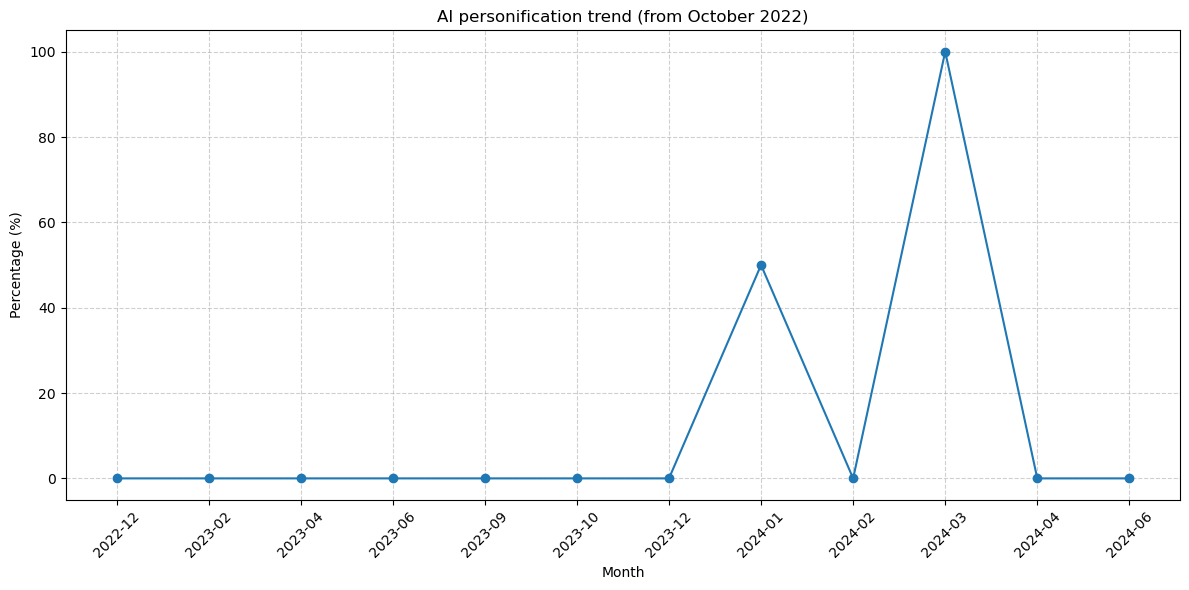

<Figure size 1200x600 with 0 Axes>

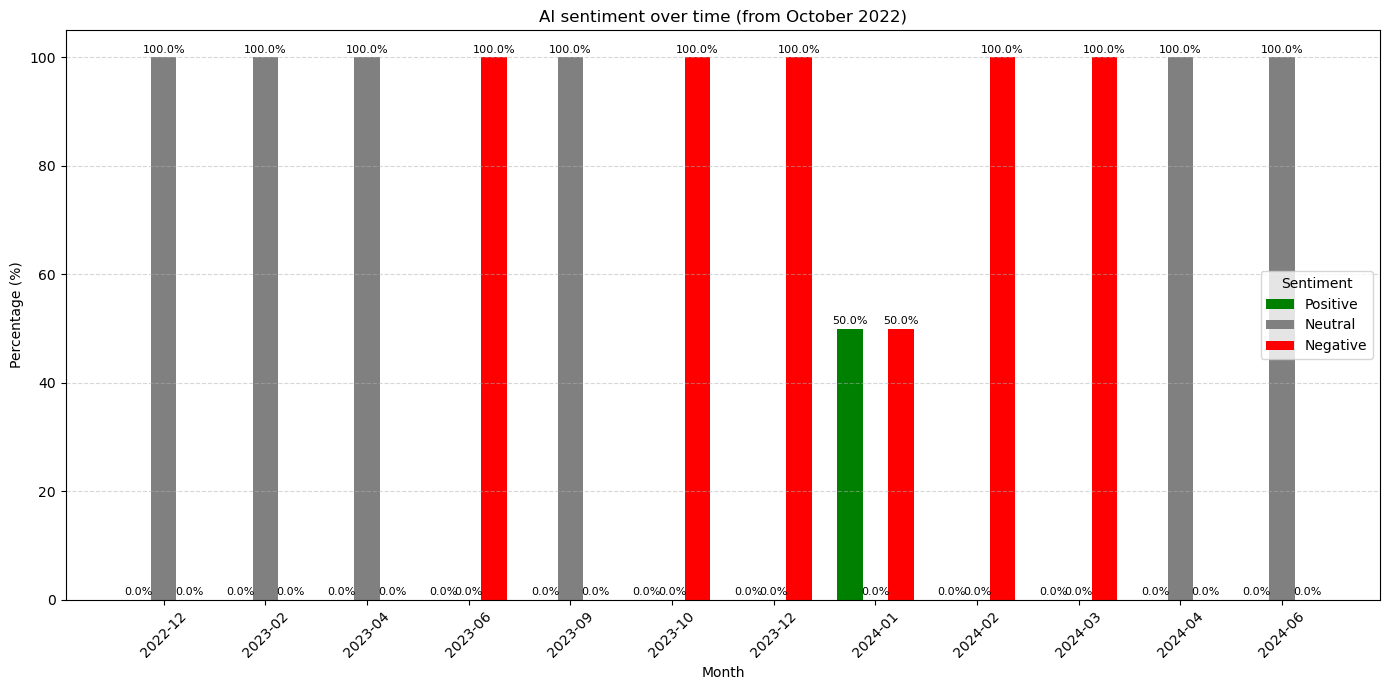

In [9]:
import pandas as pd
import spacy
import matplotlib.pyplot as plt

merged["date"] = pd.to_datetime(merged["date"], errors="coerce")
merged = merged.dropna(subset=["date"])

ai_terms = [
    "ki",
    "ai",
    "artificial intelligence",
    "künstliche intelligenz",
    "chatgpt",
    "gemini",
    "openai"
]

humanization_verbs = [
    "denkt",
    "fühlt",
    "meint",
    "sagt",
    "antwortet",
    "weiß",
    "glaubt",
    "liebt",
    "mag",
    "weint",
    "träumt",
    "hasst",
    "schämt",
    "versucht"
]

pronoun_patterns = [
    "sie denkt",
    "sie fühlt",
    "sie meint",
    "sie sagt",
    "sie antwortet",
    "er denkt",
    "er fühlt",
    "er meint",
    "er sagt",
    "er antwortet",
    "es denkt",
    "es fühlt",
    "es meint",
    "es sagt",
    "es antwortet"
]

nlp = spacy.load("de_core_news_sm")


def detect_personification(text):
    text = str(text).lower()

    if not any(term in text for term in ai_terms):
        return False

    if any(phrase in text for phrase in pronoun_patterns):
        return True

    doc = nlp(text)

    for sent in doc.sents:
        sent_text = sent.text.lower()

        if any(term in sent_text for term in ai_terms):
            if any(verb in sent_text for verb in humanization_verbs):
                return True

    return False


merged["personification"] = merged["text"].apply(
    detect_personification
)

examples = merged[
    merged["personification"]
].head(10)

print("Examples of personification:")
for i, row in examples.iterrows():
    print(f"{i + 1}. {row['text']}\n---")

merged = merged[
    merged["date"] >= "2022-10-01"
].copy()

merged["month"] = merged["date"].dt.to_period("M")

monthly_stats = (
    merged.groupby("month")
    .agg(
        total_posts=("text", "count"),
        personification_count=("personification", "sum"),
        positive=("label", lambda x: (x == "positive").sum()),
        neutral=("label", lambda x: (x == "neutral").sum()),
        negative=("label", lambda x: (x == "negative").sum())
    )
    .reset_index()
)

monthly_stats["personification_pct"] = (
    monthly_stats["personification_count"]
    / monthly_stats["total_posts"]
    * 100
)

monthly_stats["positive_pct"] = (
    monthly_stats["positive"]
    / monthly_stats["total_posts"]
    * 100
)

monthly_stats["neutral_pct"] = (
    monthly_stats["neutral"]
    / monthly_stats["total_posts"]
    * 100
)

monthly_stats["negative_pct"] = (
    monthly_stats["negative"]
    / monthly_stats["total_posts"]
    * 100
)

monthly_stats.to_csv(
    "monthly_personification_sentiment.csv",
    index=False
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_stats["month"].astype(str),
    monthly_stats["personification_pct"],
    marker="o"
)

plt.title("AI personification trend (from October 2022)")
plt.xlabel("Month")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

plt.figure(figsize=(14, 7))

x = range(len(monthly_stats))
width = 0.25

positive_bars = plt.bar(
    [i - width for i in x],
    monthly_stats["positive_pct"],
    width=width,
    color="green",
    label="Positive"
)

neutral_bars = plt.bar(
    x,
    monthly_stats["neutral_pct"],
    width=width,
    color="gray",
    label="Neutral"
)

negative_bars = plt.bar(
    [i + width for i in x],
    monthly_stats["negative_pct"],
    width=width,
    color="red",
    label="Negative"
)

for bars in [positive_bars, neutral_bars, negative_bars]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.5,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.title(
    "AI sentiment over time (from October 2022)"
)

plt.xlabel("Month")
plt.ylabel("Percentage (%)")

plt.xticks(
    list(x),
    monthly_stats["month"].astype(str),
    rotation=45
)

plt.legend(
    title="Sentiment"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

In [10]:
import spacy
from spacy.lang.de.stop_words import STOP_WORDS
from collections import Counter

nlp = spacy.load("de_core_news_sm")

keywords = [
    "ki",
    "ai",
    "chatgpt",
    "gemini",
    "openai",
    "künstliche intelligenz",
    "artificial intelligence"
]

all_words = []

for doc in nlp.pipe(
    merged["text"].fillna("").astype(str).str.lower(),
    batch_size=50
):
    if not any(keyword in doc.text for keyword in keywords):
        continue

    for token in doc:
        word = token.text.lower()

        if (
            word.isalpha()
            and word not in STOP_WORDS
            and len(word) > 2
        ):
            all_words.append(word)

word_counts = Counter(all_words)

print("Top 20 most frequent words in AI-related texts:\n")

for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

Top 20 most frequent words in AI-related texts:

artificial: 4
intelligence: 4
openai: 3
chatgpt: 2
prompts: 2
angst: 2
gemini: 2
kunst: 2
anscheinend: 1
beigebracht: 1
menschliche: 1
arroganz: 1
perfekt: 1
imitiert: 1
super: 1
nett: 1
geduld: 1
bedankt: 1
fast: 1
menschlich: 1


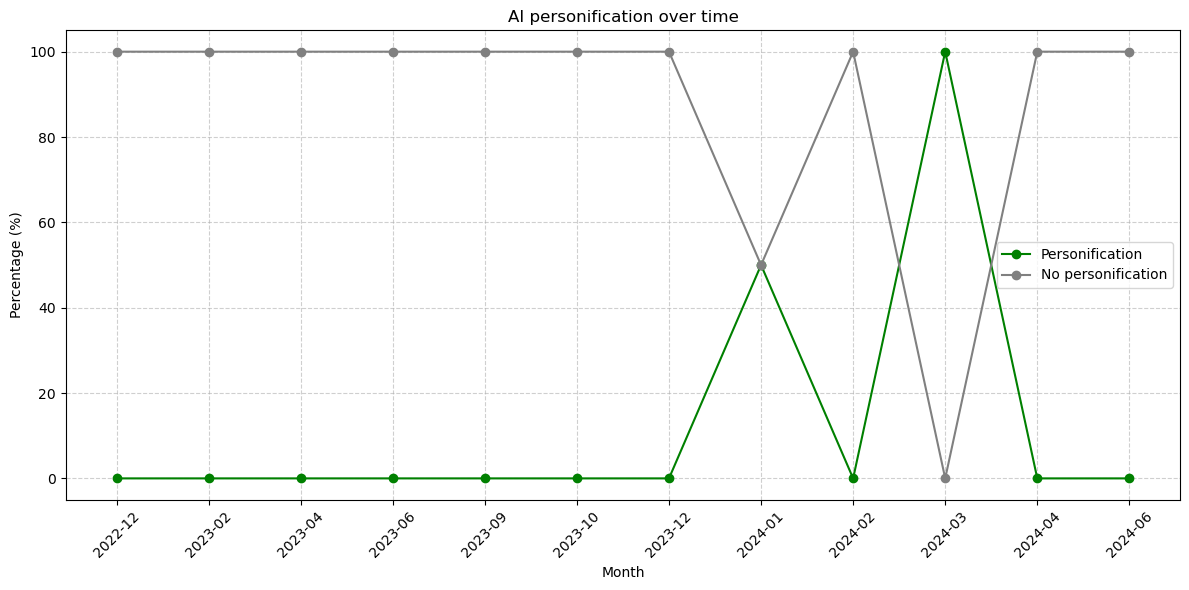

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df_person = merged.copy()

df_person["month"] = df_person["date"].dt.to_period("M")

monthly_trends = (
    df_person.groupby(["month", "personification"])
    .size()
    .unstack(fill_value=0)
)

monthly_trends = monthly_trends.reindex(
    columns=[True, False],
    fill_value=0
)

monthly_trends.columns = [
    "Personification",
    "No personification"
]

monthly_trends_pct = (
    monthly_trends.div(
        monthly_trends.sum(axis=1),
        axis=0
    ) * 100
)

monthly_trends.to_csv(
    "personification_trends_counts.csv"
)

monthly_trends_pct.to_csv(
    "personification_trends_percent.csv"
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_trends_pct.index.astype(str),
    monthly_trends_pct["Personification"],
    color="green",
    marker="o",
    label="Personification"
)

plt.plot(
    monthly_trends_pct.index.astype(str),
    monthly_trends_pct["No personification"],
    color="gray",
    marker="o",
    label="No personification"
)

plt.title("AI personification over time")
plt.xlabel("Month")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [12]:
import spacy
from spacy.lang.de.stop_words import STOP_WORDS
from collections import Counter

nlp = spacy.load("de_core_news_sm")

keywords = [
    "ki",
    "ai",
    "chatgpt",
    "gemini",
    "openai",
    "künstliche intelligenz",
    "artificial intelligence"
]

collocation_words = []

for text in merged["text"].fillna("").astype(str).str.lower():
    doc = nlp(text)
    tokens = list(doc)

    for i, token in enumerate(tokens):

        if token.text.lower() not in keywords:
            continue

        start = max(i - 5, 0)
        end = min(i + 6, len(tokens))

        for t in tokens[start:end]:
            lemma = t.lemma_.lower()

            if (
                lemma.isalpha()
                and lemma not in STOP_WORDS
                and len(lemma) > 2
                and lemma not in keywords
            ):
                collocation_words.append(lemma)

counts = Counter(collocation_words)

print("Top 20 collocations around AI-related terms:\n")

for word, count in counts.most_common(20):
    print(f"{word}: {count}")

Top 20 collocations around AI-related terms:

neu: 2
anscheinend: 1
beibringen: 1
super: 1
nett: 1
pur: 1
wut: 1
midjourney: 1
prompt: 1
komplett: 1
ignorieren: 1
sprachausgabe: 1
atmen: 1
seufzt: 1
laune: 1
retten: 1
stiehlen: 1
kunst: 1
echt: 1
schmollen: 1


In [13]:
import pandas as pd
import re
from sentence_transformers import SentenceTransformer, util

df_person = merged.copy()

def detect_personification(text):
    patterns = [
        r"chatgpt|gemini|ki|ai|openai|künstliche intelligenz|artificial intelligence",
        r"(rede mit|sprich mit|frag die ki|fragte die ki)",
        r"(antwortete|sagte|meinte|fragte)"
    ]

    text = str(text).lower()

    return any(
        re.search(pattern, text)
        for pattern in patterns
    )


df_person["personalization"] = df_person["text"].apply(
    detect_personification
)

df_person = df_person[
    df_person["personalization"]
].copy()

regex_rules = {
    "chat_partner": r"(chatgpt.*(sagte|meinte|antwortete|fragte)|rede mit|sprich mit|frag die ki)",
    "super_ki": r"(allwissend|super[- ]?ki|überlegen|genie|mächtig|beste ki|intelligenteste)",
    "fehlerhafte_ki": r"(macht fehler|stimmt nicht|kann nicht|unsinn|blöd|falsch|rechnet falsch)",
    "handlungsfaehige_ki": r"(ki .* (entscheidet|übernimmt|schreibt|liefert|hilft|macht))",
    "ironische_personifikation": r"(witz|lustig|sarkasmus|lol|blödsinn|quatsch)"
}


def regex_categorize(text):
    text = str(text).lower()

    for category, pattern in regex_rules.items():
        if re.search(pattern, text):
            return category

    return None


df_person["category_regex"] = df_person["text"].apply(
    regex_categorize
)

model = SentenceTransformer(
    "distiluse-base-multilingual-cased-v2"
)

examples = {
    "chat_partner": [
        "Ich fragte die KI um Hilfe",
        "ChatGPT antwortete mir"
    ],
    "super_ki": [
        "die mächtigste KI der Welt",
        "allwissende Super-KI"
    ],
    "fehlerhafte_ki": [
        "die KI lag falsch",
        "ChatGPT macht Fehler"
    ],
    "handlungsfaehige_ki": [
        "die KI schreibt den Text",
        "die KI übernimmt die Analyse"
    ],
    "ironische_personifikation": [
        "KI macht Witze",
        "lustige KI"
    ]
}

example_labels = list(examples.keys())

example_embeddings = {
    label: model.encode(
        examples[label],
        convert_to_tensor=True
    )
    for label in example_labels
}


def embed_classify(text):
    embedding = model.encode(
        str(text),
        convert_to_tensor=True
    )

    scores = []

    for label in example_labels:
        similarity = util.cos_sim(
            embedding,
            example_embeddings[label]
        ).max().item()

        scores.append(similarity)

    return example_labels[scores.index(max(scores))]


df_person["category_final"] = df_person.apply(
    lambda row:
        row["category_regex"]
        if pd.notna(row["category_regex"])
        else embed_classify(row["text"]),
    axis=1
)

df_person.to_excel(
    "personification_categorized_hybrid.xlsx",
    index=False
)

print("Personification categories:")
print(df_person["category_final"].value_counts())

print("\nSaved: personification_categorized_hybrid.xlsx")

Personification categories:
category_final
chat_partner                 4
fehlerhafte_ki               3
handlungsfaehige_ki          3
super_ki                     2
ironische_personifikation    1
Name: count, dtype: int64

Saved: personification_categorized_hybrid.xlsx


Categories:
category_final
chat_partner                 4
fehlerhafte_ki               3
handlungsfaehige_ki          3
super_ki                     2
ironische_personifikation    1
Name: count, dtype: int64


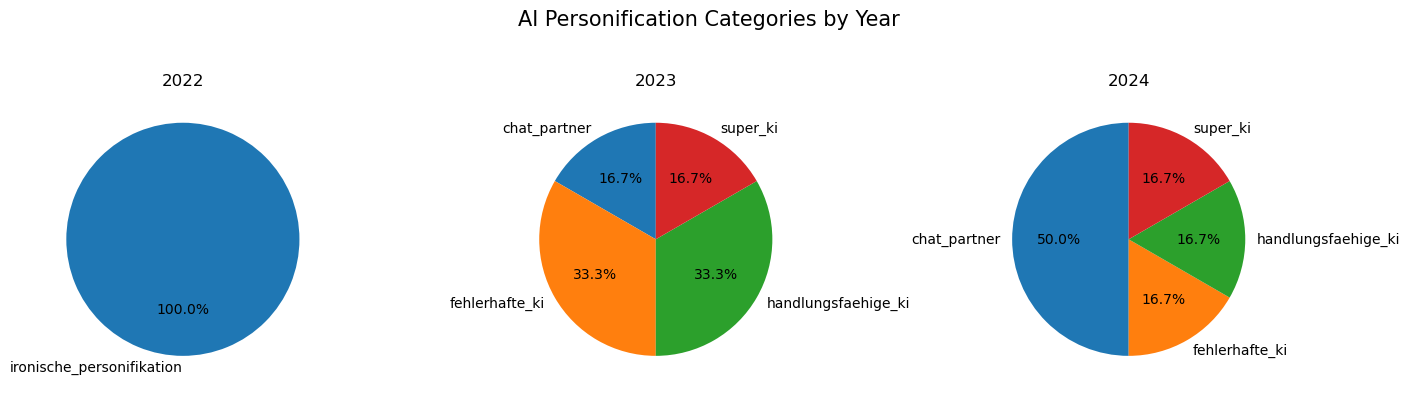


=== Examples: fehlerhafte_ki ===
1. OpenAI hat GPT-5 anscheinend beigebracht, wie man menschliche Arroganz perfekt imitiert.

2. artificial intelligence versucht verzweifelt, Kunst zu verstehen, aber ihr fehlt einfach das Herz.

3. KI stiehlt die Kunst von echten Menschen und feiert sich dann selbst für das Ergebnis.


=== Examples: chat_partner ===
1. Ich spüre pure Wut, wenn  AI Midjourney meine Prompts komplett ignoriert und stur sein eigenes Ding macht.

2. Ich feiere  ChatGPT total, er ist wie der schlaue, geduldige große Bruder, den ich nie hatte.

3. ChatGPT hat sich heute super nett für meine Geduld bedankt, das hat sich fast schon menschlich angefühlt.

4. Es macht mir Angst, wie intelligent diese  artificial intelligence Algorithmen geworden sind. Die Technologie überholt uns im Schlaf.


=== Examples: super_ki ===
1. Die  künstliche Intelligenz schläft nie, sie beobachtet uns ständig durch unsere eigenen Prompts.

2. Diese  artificial intelligence Systeme tun immer so, als 

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel(
    "personification_categorized_hybrid.xlsx"
)

df.columns = df.columns.str.strip()

if "date" not in df.columns:
    raise ValueError(
        f"Missing 'date' column. Available: {df.columns.tolist()}"
    )

if "category_final" not in df.columns:
    raise ValueError(
        "Missing 'category_final' column"
    )

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

df = df.dropna(subset=["date"])

df = df[
    df["date"] >= "2022-01-01"
].copy()

df["month"] = df["date"].dt.to_period("M")

print("Categories:")
print(df["category_final"].value_counts())

monthly_counts = (
    df.groupby(["month", "category_final"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

if monthly_counts.empty:
    raise ValueError("No data available after grouping.")

monthly_pct = (
    monthly_counts.div(
        monthly_counts.sum(axis=1),
        axis=0
    ).fillna(0) * 100
)

monthly_counts.to_csv(
    "personification_monthly_counts.csv"
)

monthly_pct.to_csv(
    "personification_monthly_percent.csv"
)

yearly_counts = (
    df.groupby(["date", "category_final"])
    .size()
    .unstack(fill_value=0)
)

yearly_counts.index = yearly_counts.index.year

yearly_counts = (
    df.groupby(["date", "category_final"])
    .size()
    .unstack(fill_value=0)
)

yearly_counts.index = pd.to_datetime(
    yearly_counts.index
).year

yearly_counts = yearly_counts.groupby(
    yearly_counts.index
).sum()

categories = yearly_counts.columns

colors = plt.cm.tab10(
    range(len(categories))
)

years = yearly_counts.index
n_years = len(years)

cols = 3
rows = (n_years + cols - 1) // cols

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(14, rows * 4)
)

axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, year in zip(axes, years):

    values = yearly_counts.loc[year]

    values = values[
        values > 0
    ]

    ax.pie(
        values,
        labels=values.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors[:len(values)]
    )

    ax.set_title(
        f"{year}"
    )

for ax in axes[n_years:]:
    ax.axis("off")

fig.suptitle(
    "AI Personification Categories by Year",
    fontsize=15
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()


def show_examples(category, n=5):
    subset = df[
        df["category_final"] == category
    ]

    print(f"\n=== Examples: {category} ===")

    samples = subset["text"].dropna().sample(
        n=min(n, len(subset)),
        random_state=42
    )

    for i, text in enumerate(samples, 1):
        print(f"{i}. {text}\n")


for category in df["category_final"].dropna().unique():
    show_examples(category, n=5)

print(
    "\nSaved: personification_monthly_counts.csv"
)

print(
    "Saved: personification_monthly_percent.csv"
)

=== Sentiment values ===
bert_sentiment
neutral     6
negative    6
positive    1
Name: count, dtype: int64

=== Distribution of personification categories ===
category_final
chat_partner                 4
fehlerhafte_ki               3
handlungsfaehige_ki          3
super_ki                     2
ironische_personifikation    1
Name: count, dtype: int64


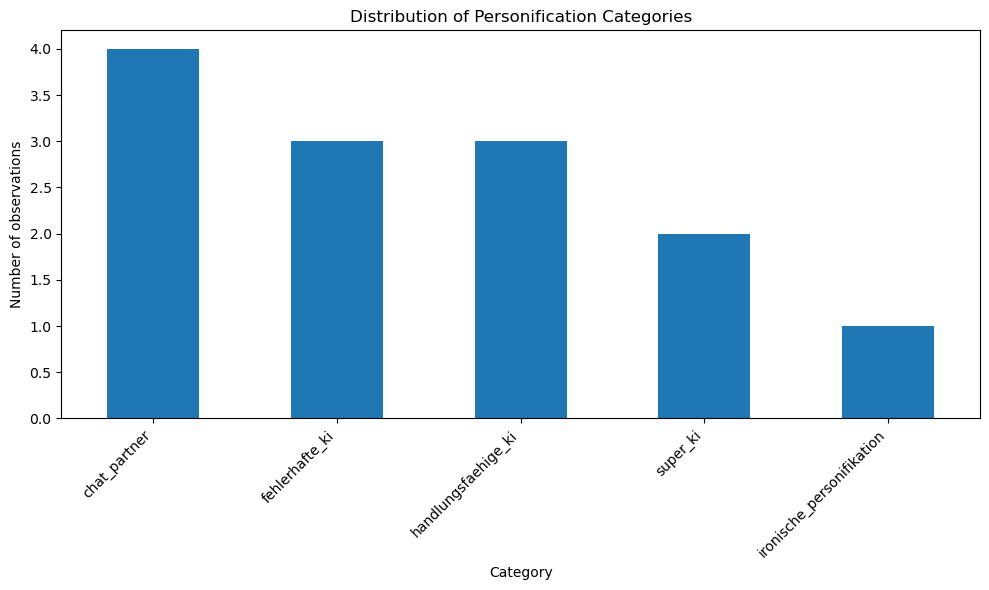


=== Sentiment distribution per category ===
bert_sentiment             negative  neutral  positive
category_final                                        
chat_partner                      2        1         1
fehlerhafte_ki                    1        2         0
handlungsfaehige_ki               2        1         0
ironische_personifikation         0        1         0
super_ki                          1        1         0

=== Percentage distribution of sentiment ===
bert_sentiment             negative  neutral  positive
category_final                                        
chat_partner                  50.00    25.00      25.0
fehlerhafte_ki                33.33    66.67       0.0
handlungsfaehige_ki           66.67    33.33       0.0
ironische_personifikation      0.00   100.00       0.0
super_ki                      50.00    50.00       0.0


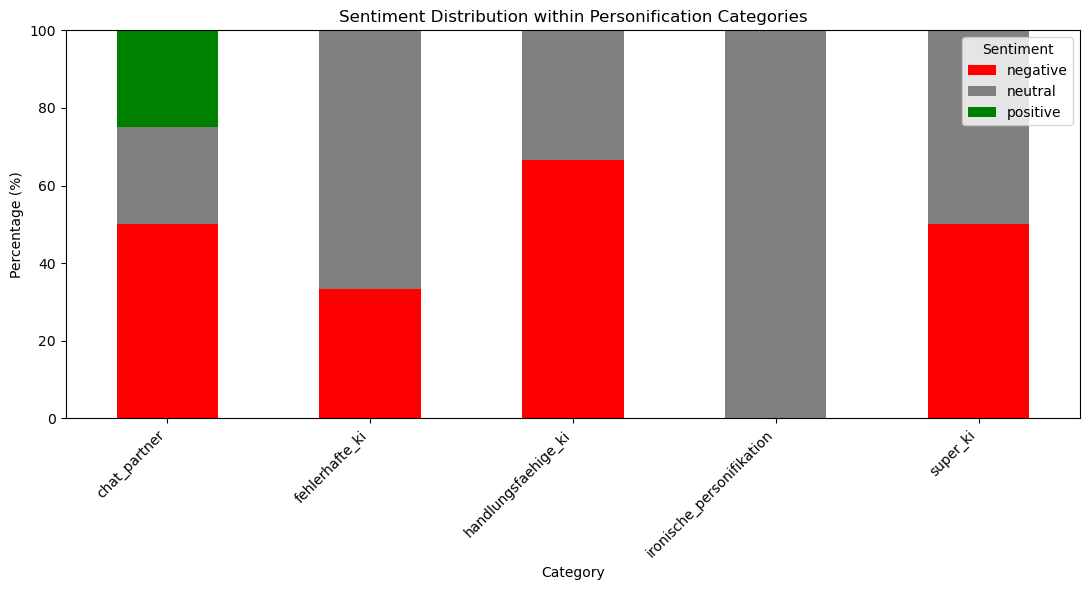


Saved:
- personification_categorized_with_sentiment.xlsx
- sentiment_counts_per_category.csv
- sentiment_percent_per_category.csv
- category_distribution.png
- sentiment_per_category.png


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

FILE = "personification_categorized_hybrid.xlsx"

df_categories = pd.read_excel(FILE)
df_categories.columns = df_categories.columns.str.strip()

if "category_final" not in df_categories.columns:
    raise ValueError(
        f"Missing 'category_final'. Available columns: {df_categories.columns.tolist()}"
    )

df_categories["category_final"] = (
    df_categories["category_final"]
    .fillna("unknown")
)

if "text" not in df_categories.columns:
    raise ValueError(
        f"Missing 'text' column. Available columns: {df_categories.columns.tolist()}"
    )

sentiment_data = merged[
    ["text", "label"]
].copy()

sentiment_data = sentiment_data.rename(
    columns={"label": "bert_sentiment"}
)

df = df_categories.merge(
    sentiment_data,
    on="text",
    how="left"
)

df["bert_sentiment"] = (
    df["bert_sentiment"]
    .fillna("unknown")
    .astype(str)
    .str.lower()
)

print("=== Sentiment values ===")
print(df["bert_sentiment"].value_counts())

category_counts = (
    df["category_final"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\n=== Distribution of personification categories ===")
print(category_counts)

plt.figure(figsize=(10, 6))

category_counts.plot(
    kind="bar"
)

plt.title("Distribution of Personification Categories")
plt.xlabel("Category")
plt.ylabel("Number of observations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    "category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


sentiment_dist = (
    df.groupby(
        ["category_final", "bert_sentiment"]
    )
    .size()
    .unstack(fill_value=0)
)

sentiment_order = [
    "negative",
    "neutral",
    "positive"
]

for sentiment in sentiment_order:
    if sentiment not in sentiment_dist.columns:
        sentiment_dist[sentiment] = 0

sentiment_dist = sentiment_dist[
    sentiment_order
]

print("\n=== Sentiment distribution per category ===")
print(sentiment_dist)


sentiment_pct = (
    sentiment_dist
    .div(
        sentiment_dist.sum(axis=1),
        axis=0
    )
    .fillna(0)
    * 100
)

print("\n=== Percentage distribution of sentiment ===")
print(sentiment_pct.round(2))


colors_map = {
    "negative": "red",
    "neutral": "gray",
    "positive": "green"
}

colors = [
    colors_map[sentiment]
    for sentiment in sentiment_pct.columns
]

ax = sentiment_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=colors
)

plt.title(
    "Sentiment Distribution within Personification Categories"
)
plt.xlabel("Category")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.legend(title="Sentiment")

plt.tight_layout()

plt.savefig(
    "sentiment_per_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


df.to_excel(
    "personification_categorized_with_sentiment.xlsx",
    index=False
)

sentiment_dist.to_csv(
    "sentiment_counts_per_category.csv"
)

sentiment_pct.to_csv(
    "sentiment_percent_per_category.csv"
)

print("\nSaved:")
print("- personification_categorized_with_sentiment.xlsx")
print("- sentiment_counts_per_category.csv")
print("- sentiment_percent_per_category.csv")
print("- category_distribution.png")
print("- sentiment_per_category.png")

In [16]:
import pandas as pd

df = pd.read_excel(
    "personification_categorized_with_sentiment.xlsx"
)

df.columns = df.columns.str.strip()

required_cols = ["category_final", "text", "bert_sentiment"]

for col in required_cols:
    if col not in df.columns:
        raise ValueError(
            f"Missing column: {col}. Available: {df.columns.tolist()}"
        )

chat_partner_df = df[
    df["category_final"] == "chat_partner"
].copy()

if chat_partner_df.empty:
    print("No rows for category: chat_partner")
else:
    sentiments = (
        chat_partner_df["bert_sentiment"]
        .dropna()
        .unique()
    )

    print("Available sentiment values:", sentiments)

    for sentiment in sentiments:
        subset = chat_partner_df[
            chat_partner_df["bert_sentiment"] == sentiment
        ]

        print(f"\n=== Examples of sentiment: {sentiment} ===\n")

        samples = subset["text"].dropna().sample(
            n=min(50, len(subset)),
            random_state=42
        )

        for i, text in enumerate(samples, 1):
            print(f"{i}. {text}\n")

Available sentiment values: ['positive' 'negative' 'neutral']

=== Examples of sentiment: positive ===

1. ChatGPT hat sich heute super nett für meine Geduld bedankt, das hat sich fast schon menschlich angefühlt.


=== Examples of sentiment: negative ===

1. Es macht mir Angst, wie intelligent diese  artificial intelligence Algorithmen geworden sind. Die Technologie überholt uns im Schlaf.

2. Ich spüre pure Wut, wenn  AI Midjourney meine Prompts komplett ignoriert und stur sein eigenes Ding macht.


=== Examples of sentiment: neutral ===

1. Ich feiere  ChatGPT total, er ist wie der schlaue, geduldige große Bruder, den ich nie hatte.

